# Library 

In [70]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# Get the dataset

In [71]:
df = pd.read_csv("IMDB_preprocessed.csv")

df.head()

,review,sentiment,label
0,one reviewers mention watch oz episode youll h...,positive,1
1,wonderful little production film technique una...,positive,1
2,think wonderful way spend time hot summer week...,positive,1
3,basically theres family little boy jake think ...,negative,0
4,petter matteis love time money visually stun f...,positive,1


# Train and test data

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (40000,)
Test size: (10000,)


# Bayes classification

## One Hot Encoding

In [73]:
text_pipeline_bayes_one = Pipeline(
    steps=[
        ("encoding", CountVectorizer(binary=True,stop_words='english', ngram_range=(1, 2), max_features=5000)),
        ("classifier", MultinomialNB())
    ]
)

text_pipeline_bayes_one.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoding', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [74]:
y_pred_bayes_one = text_pipeline_bayes_one.predict(X_test)
y_proba_bayes_one = text_pipeline_bayes_one.predict_proba(X_test)

In [75]:
results_bayes_one = pd.DataFrame({
    "true_result": y_test.values,
    "predicted_class": y_pred_bayes_one,
    "predicted_probability_positive": y_proba_bayes_one[:,1]
})

results_bayes_one.head(10)

,true_result,predicted_class,predicted_probability_positive
0,0,0,1.844952e-03
1,0,1,9.872877e-01
2,1,1,9.994445e-01
3,0,0,1.839477e-03
4,0,0,1.118272e-05
5,0,0,9.409117e-06
6,0,0,7.894022e-06
7,0,1,6.678353e-01
8,0,0,2.652051e-01
9,0,0,5.140331e-12


#### Accuracy, Precision, Recall, F1-score of OneHotEncoding

In [76]:
accuracy_bayes_one = accuracy_score(y_test, y_pred_bayes_one)
precision_bayes_one = precision_score(y_test, y_pred_bayes_one)
recall_bayes_one = recall_score(y_test, y_pred_bayes_one)
f1_bayes_one = f1_score(y_test, y_pred_bayes_one)

print(f"Accuracy:  {accuracy_bayes_one}")
print(f"Precision: {precision_bayes_one}")
print(f"Recall:    {recall_bayes_one}")
print(f"F1-score:  {f1_bayes_one}")

Accuracy:  0.8572
Precision: 0.8531039936733887
Recall:    0.863
F1-score:  0.8580234639093259


In [77]:
print(classification_report(
    y_test,
    y_pred_bayes_one,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.86      0.85      0.86      5000
    Positive       0.85      0.86      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



#### Train and test score

In [78]:
y_train_bayes_one = text_pipeline_bayes_one.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_bayes_one)
test_accuracy = accuracy_score(y_test, y_pred_bayes_one)
print(f"Training accuracy: {train_accuracy}")
print(f"Testing accuracy: {test_accuracy}")

train_precision = precision_score(y_train, y_train_bayes_one)
test_precision = precision_score(y_test, y_pred_bayes_one)
print(f"Training precision: {train_precision}")
print(f"Testing precision: {test_precision}")

train_recall = recall_score(y_train,y_train_bayes_one)
test_recall = recall_score(y_test, y_pred_bayes_one)
print(f"Training recall: {train_recall}")
print(f"Testing recall: {test_recall}")

train_f1_score = f1_score(y_train,y_train_bayes_one)
test_f1_score = f1_score(y_test,y_pred_bayes_one)
print(f"Training F1-score: {train_f1_score}")
print(f"Testing F1-score: {test_f1_score}")

Training accuracy: 0.85815
Testing accuracy: 0.8572
Training precision: 0.8561201153425475
Testing precision: 0.8531039936733887
Training recall: 0.861
Testing recall: 0.863
Training F1-score: 0.8585531235977464
Testing F1-score: 0.8580234639093259


#### Confusion matrix of OneHotEncoding

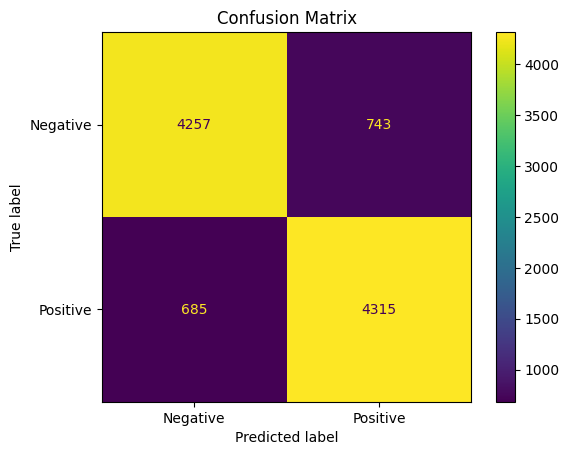

In [79]:
cm_bayes_one = confusion_matrix(y_test, y_pred_bayes_one)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bayes_one,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Bag of Words

In [80]:
text_pipeline_bayes_bag = Pipeline(
    steps=[
        ("encoding", CountVectorizer(stop_words='english', ngram_range=(1, 2), max_features=5000)),
        ("classifier", MultinomialNB())
    ]
)

text_pipeline_bayes_bag.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoding', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [81]:
y_pred_bayes_bag = text_pipeline_bayes_bag.predict(X_test)
y_proba_bayes_bag = text_pipeline_bayes_bag.predict_proba(X_test)

In [82]:
results_bayes_bag = pd.DataFrame({
    "true_result": y_test.values,
    "predicted_class": y_pred_bayes_bag,
    "predicted_probability_positive": y_proba_bayes_bag[:,1]
})

results_bayes_bag.head(10)

,true_result,predicted_class,predicted_probability_positive
0,0,0,6.614810e-04
1,0,1,9.965265e-01
2,1,1,9.975129e-01
3,0,0,6.724851e-04
4,0,0,2.315708e-06
5,0,0,5.910456e-06
6,0,0,8.927963e-08
7,0,1,6.944843e-01
8,0,0,2.353202e-01
9,0,0,3.494467e-17


#### Accuracy, Precision, Recall, F1-score of Bag of Words

In [83]:
accuracy_bayes_bag = accuracy_score(y_test, y_pred_bayes_bag)
precision_bayes_bag = precision_score(y_test, y_pred_bayes_bag)
recall_bayes_bag = recall_score(y_test, y_pred_bayes_bag)
f1_bayes_bag = f1_score(y_test, y_pred_bayes_bag)

print(f"Accuracy:  {accuracy_bayes_bag}")
print(f"Precision: {precision_bayes_bag}")
print(f"Recall:    {recall_bayes_bag}")
print(f"F1-score:  {f1_bayes_bag}")

Accuracy:  0.8443
Precision: 0.8417708953742307
Recall:    0.848
F1-score:  0.844873966324599


In [84]:
print(classification_report(
    y_test,
    y_pred_bayes_bag,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.85      0.84      0.84      5000
    Positive       0.84      0.85      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



#### Train and test score

In [85]:
y_train_bayes_bag = text_pipeline_bayes_bag.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_bayes_bag)
test_accuracy = accuracy_score(y_test, y_pred_bayes_bag)
print(f"Training accuracy: {train_accuracy}")
print(f"Testing accuracy: {test_accuracy}")

train_precision = precision_score(y_train, y_train_bayes_bag)
test_precision = precision_score(y_test, y_pred_bayes_bag)
print(f"Training precision: {train_precision}")
print(f"Testing precision: {test_precision}")

train_recall = recall_score(y_train,y_train_bayes_bag)
test_recall = recall_score(y_test, y_pred_bayes_bag)
print(f"Training recall: {train_recall}")
print(f"Testing recall: {test_recall}")

train_f1_score = f1_score(y_train,y_train_bayes_bag)
test_f1_score = f1_score(y_test,y_pred_bayes_bag)
print(f"Training F1-score: {train_f1_score}")
print(f"Testing F1-score: {test_f1_score}")

Training accuracy: 0.85045
Testing accuracy: 0.8443
Training precision: 0.8488453115667928
Testing precision: 0.8417708953742307
Training recall: 0.85275
Testing recall: 0.848
Training F1-score: 0.8507931756958994
Testing F1-score: 0.844873966324599


#### Confusion matrix of Bag of Words

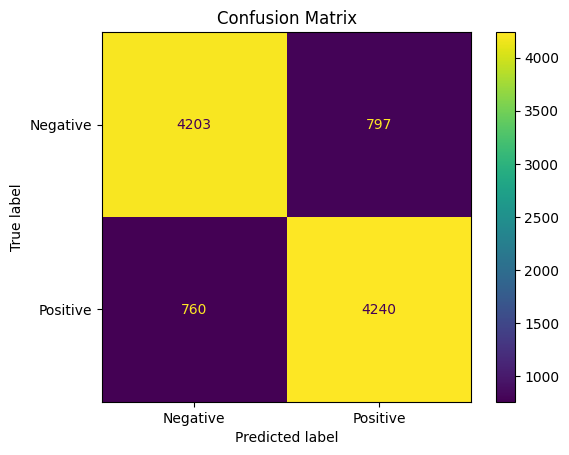

In [86]:
cm_bayes_bag = confusion_matrix(y_test, y_pred_bayes_bag)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bayes_bag,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## TF-IDF

In [87]:
text_pipeline_bayes_tfidf = Pipeline(
    steps=[
        ("encoding", TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=5000)),
        ("classifier", MultinomialNB())
    ]
)

text_pipeline_bayes_tfidf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoding', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [88]:
y_pred_bayes_tfidf = text_pipeline_bayes_tfidf.predict(X_test)
y_proba_bayes_tfidf = text_pipeline_bayes_tfidf.predict_proba(X_test)

In [89]:
results_bayes_tfidf = pd.DataFrame({
    "true_result": y_test.values,
    "predicted_class": y_pred_bayes_tfidf,
    "predicted_probability_positive": y_proba_bayes_tfidf[:,1]
})

results_bayes_tfidf.head(10)

,true_result,predicted_class,predicted_probability_positive
0,0,0,0.261312
1,0,1,0.707004
2,1,1,0.707600
3,0,0,0.296885
4,0,0,0.171133
5,0,0,0.136270
6,0,0,0.227762
7,0,1,0.596038
8,0,0,0.479199
9,0,0,0.057399


#### Accuracy, Precision, Recall, F1-score of TF - IDF

In [90]:
accuracy_bayes_tfidf = accuracy_score(y_test, y_pred_bayes_tfidf)
precision_bayes_tfidf = precision_score(y_test, y_pred_bayes_tfidf)
recall_bayes_tfidf = recall_score(y_test, y_pred_bayes_tfidf)
f1_bayes_tfidf = f1_score(y_test, y_pred_bayes_tfidf)

print(f"Accuracy:  {accuracy_bayes_tfidf}")
print(f"Precision: {precision_bayes_tfidf}")
print(f"Recall:    {recall_bayes_tfidf}")
print(f"F1-score:  {f1_bayes_tfidf}")

Accuracy:  0.8542
Precision: 0.8426857585139319
Recall:    0.871
F1-score:  0.8566089693154996


In [91]:
print(classification_report(
    y_test,
    y_pred_bayes_tfidf,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.87      0.84      0.85      5000
    Positive       0.84      0.87      0.86      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



#### Train and test score

In [92]:
y_train_bayes_tfidf = text_pipeline_bayes_tfidf.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_bayes_tfidf)
test_accuracy = accuracy_score(y_test, y_pred_bayes_tfidf)
print(f"Training accuracy: {train_accuracy}")
print(f"Testing accuracy: {test_accuracy}")

train_precision = precision_score(y_train, y_train_bayes_tfidf)
test_precision = precision_score(y_test, y_pred_bayes_tfidf)
print(f"Training precision: {train_precision}")
print(f"Testing precision: {test_precision}")

train_recall = recall_score(y_train,y_train_bayes_tfidf)
test_recall = recall_score(y_test, y_pred_bayes_tfidf)
print(f"Training recall: {train_recall}")
print(f"Testing recall: {test_recall}")

train_f1_score = f1_score(y_train,y_train_bayes_tfidf)
test_f1_score = f1_score(y_test,y_pred_bayes_tfidf)
print(f"Training F1-score: {train_f1_score}")
print(f"Testing F1-score: {test_f1_score}")

Training accuracy: 0.860225
Testing accuracy: 0.8542
Training precision: 0.8505668823901513
Testing precision: 0.8426857585139319
Training recall: 0.874
Testing recall: 0.871
Training F1-score: 0.8621242386131045
Testing F1-score: 0.8566089693154996


#### Confusion matrix of TF-IDF

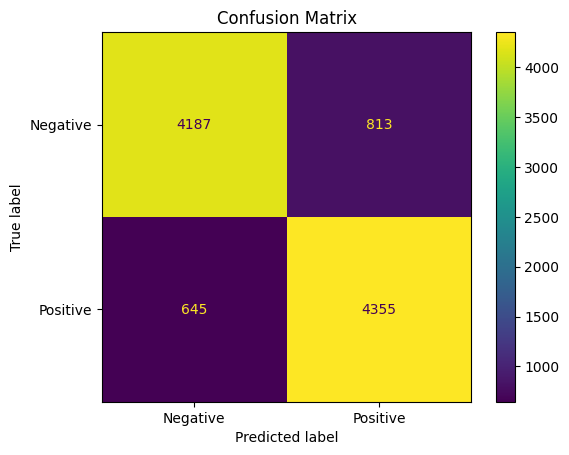

In [93]:
cm_bayes_tfidf = confusion_matrix(y_test, y_pred_bayes_tfidf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bayes_tfidf,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()